# 2. Network construction

**Network.** Nodes are the organisations that took part in at least one Horizon Europe project. Two organisations are linked if they took part in at least one project together. While the data collected describe a bipartite network, with organisations and projects as nodes and participations as links between them, the network built here is its projection onto organisations, where projects are replaced by direct links among their participants.

**Node attributes.** From `organization.csv`: name, country, NUTS region, geographic coordinates, activity type, SME flag. Aggregated over the organisation's projects, using `project_json.csv`: number of projects, number of projects coordinated, number of individual grants (ERC, MSCA), total EU contribution received, first and last year of participation, average AI relevance of its projects (`policy_ai` marker).

**Edge attributes.** `weight` = number of projects in common, `first_year` = start year of the earliest project in common.

**Construction rules.**
- *Nodes.* One per `organisationID`. Participations without identifier are excluded, since they cannot be assigned to a node (none in this snapshot).
- *Participations.* Every organisation–project pair counts once. Duplicate records of the same pair are merged: EU contribution summed, coordinator role kept if either record has it. The other differing columns are not used.
- *Roles.* All four roles recorded by CORDIS (coordinator, participant, associated partner, third party) count as participations, since all of them take part in the project work. Additionally, the role is kept in the data.
- *Terminated participations.* Kept, since the collaboration took place.
- *Single-participant projects.* They generate no edges. Their organisations remain in the network as isolated nodes, since they are part of the funding landscape.

## Imports and configuration

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Input tables produced by 01_data_collection.ipynb
CSV_DIR = Path("../data/csv/horizon_europe")
# Output folder for the network
NET_DIR = Path("../data/network")
# Output folder for the figures
FIG_DIR = Path("../figures")

NET_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Loading and cleaning

### Loading the tables

We load the two tables produced in `01_data_collection.ipynb`: the participations, which define the edges, and the projects, which provide the attributes.

In [2]:
# Load the participations: one row per organisation-project pair
participations = pd.read_csv(CSV_DIR / "organization.csv", sep=";", low_memory=False)

# Load the projects, keeping only the columns needed for the node attributes
projects = pd.read_csv(CSV_DIR / "project_json.csv", usecols=["id", "startDate", "fundingScheme", "policy_ai"])

# Start year of each project, taken from the first 4 characters of the date
projects["startYear"] = projects["startDate"].str[:4].astype("Int64")

print("participations:", len(participations))
print("projects:      ", len(projects))

participations: 145909
projects:       23613


### Cleaning the participations

Before building the network, we perform three checks on the participations. We remove those without organisation identifier, which cannot be assigned to a node. We then inspect the duplicate organisation–project pairs, i.e. organisations recorded twice in the same project, and keep one record per pair. Of the columns that differ between the two records, only three are used later: EU contribution and coordinator role are consolidated before the removal (contributions summed, coordinator if either record is), while `SME` is resolved at node level, as for any organisation with several participations, by taking the most frequent value. The remaining columns (`order`, `endOfParticipation`, `netEcContribution`, `totalCost`) are not used in the analysis, so their loss has no effect. Finally, we verify that every participation refers to a project present in the project table.

In [3]:
# Participations without organisation identifier are removed, since they cannot be assigned to a node
no_id = participations["organisationID"].isna()
participations = participations[~no_id].copy()
participations["organisationID"] = participations["organisationID"].astype(int)

# Duplicate organisation-project pairs: for each column, in how many pairs the two records differ
pair = ["projectID", "organisationID"]
dup = participations[participations.duplicated(subset=pair, keep=False)]
differing = dup.groupby(pair).nunique().gt(1).sum()

# One record is kept per pair. The participation-level attributes used later are consolidated beforehand:
# the EU contribution is summed over the records, and the pair counts as coordinator if either record is
participations["ecContribution"] = participations.groupby(pair)["ecContribution"].transform("sum")
participations["is_coordinator"] = participations.groupby(pair)["role"].transform(lambda s: (s == "coordinator").any())
participations = participations.drop_duplicates(subset=pair)

# Every participation must refer to a project present in the project table
unknown = ~participations["projectID"].isin(projects["id"])

# Summary of the cleaning
print("Cleaning summary:")
print(f"  removed, no organisationID:   {no_id.sum():>7}")
print(f"  removed, duplicated pairs:    {len(dup) // 2:>7}")
print(f"  unknown project:              {unknown.sum():>7}")
print(f"  clean participations:         {len(participations):>7}")
print(f"  organisations:                {participations['organisationID'].nunique():>7}")
print(f"  projects:                     {participations['projectID'].nunique():>7}")

print("\nColumns that differ between the two records of a duplicated pair (number of pairs):")
print(differing[differing > 0].sort_values(ascending=False).to_string())

Cleaning summary:
  removed, no organisationID:         0
  removed, duplicated pairs:        278
  unknown project:                    0
  clean participations:          145631
  organisations:                  35200
  projects:                       23613

Columns that differ between the two records of a duplicated pair (number of pairs):
order                 277
endOfParticipation    254
role                  230
netEcContribution     211
totalCost             112
ecContribution         79
SME                     3


## Data characterization

Before turning the participations into a network, we describe how they are distributed: across projects, across organisations, across countries and activity types, by role, over time, and how complete the attributes are. These distributions determine how participations map onto nodes and edges, and which attributes can support the analyses of the following parts.

### Participants per project

Each project with $n$ participants generates $\binom{n}{2}$ edges, one for every pair of participants. The distribution of the number of participants therefore determines the number of edges: projects with a single participant generate none, while a few projects with many participants can account for a large share of the total.

In [4]:
# Number of participants of each project
participants = participations.groupby("projectID").size()

# Number of edges each project generates: one for every pair of participants, n * (n - 1) / 2
edges_per_project = participants * (participants - 1) // 2

# Share of the edges generated by the 1% of projects with most participants
largest_1pct = edges_per_project.sort_values(ascending=False).head(len(edges_per_project) // 100)
share_1pct = largest_1pct.sum() / edges_per_project.sum()

print("Participants per project")
print(f"  projects with a single participant:   {(participants == 1).sum():>7}  ({(participants == 1).mean():.1%})")
print(f"  median participants per project:      {participants.median():>7.0f}")
print(f"  maximum participants in a project:    {participants.max():>7}")
print(f"  edges generated (with multiplicity):  {edges_per_project.sum():>7}")
print(f"  share generated by the largest 1%:    {share_1pct:>7.1%}")

Participants per project
  projects with a single participant:     11072  (46.9%)
  median participants per project:            2
  maximum participants in a project:        199
  edges generated (with multiplicity):  1335249
  share generated by the largest 1%:      30.4%


Almost half of the projects (46.9%) have a single participant, and therefore generate no edges. These projects also drive the median down to two participants. A few projects are very large (up to 199 participants), and the 1% of projects with most participants generate 30% of all the edges. The network will therefore be built from many collaborations of moderate size and a few very large cliques.

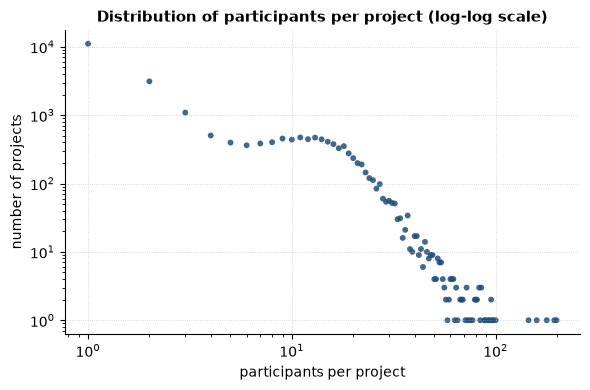

In [5]:
# Distribution of the number of participants per project (log-log scale)
counts = participants.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(counts.index, counts.values, s=18, color="#1f4e79", alpha=0.85, edgecolor="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("participants per project")
ax.set_ylabel("number of projects")
ax.set_title("Distribution of participants per project (log-log scale)", fontsize=11, fontweight="bold")
ax.grid(True, which="major", linestyle=":", linewidth=0.6, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "participants_per_project.png", dpi=200)
plt.show()

On log-log axes the distribution is not a straight line, so it does not appear to follow a power law. Three regions can be distinguished: a sharp drop from single-participant projects (over 10,000) to projects with two or three participants, a plateau between roughly 5 and 15 participants, where each value counts a few hundred projects, and a fast decay beyond 20 participants, with very few projects above 100.

### Projects per organisation

We count in how many projects each organisation takes part. This distribution shows whether activity is spread across many organisations or concentrated on a few very active ones.

In [6]:
# Number of projects of each organisation
projects_per_org = participations.groupby("organisationID").size()

# Share of the participations held by the 1% of organisations with most projects
most_active_1pct = projects_per_org.sort_values(ascending=False).head(len(projects_per_org) // 100)
share_1pct = most_active_1pct.sum() / projects_per_org.sum()

print("Projects per organisation")
print(f"  organisations with a single project:   {(projects_per_org == 1).sum():>7}  ({(projects_per_org == 1).mean():.1%})")
print(f"  median projects per organisation:      {projects_per_org.median():>7.0f}")
print(f"  maximum projects of an organisation:   {projects_per_org.max():>7}")
print(f"  share held by the most active 1%:      {share_1pct:>7.1%}")

Projects per organisation
  organisations with a single project:     22025  (62.6%)
  median projects per organisation:            1
  maximum projects of an organisation:      1432
  share held by the most active 1%:        35.1%


Activity is highly concentrated. Almost two thirds of the organisations (62.6%) take part in a single project, and the median is one. At the other end, the most active organisation appears in 1,432 projects, and the 1% most active organisations hold 35% of all participations. The network will thus be made of a large majority of occasional participants and a small core of very active ones.

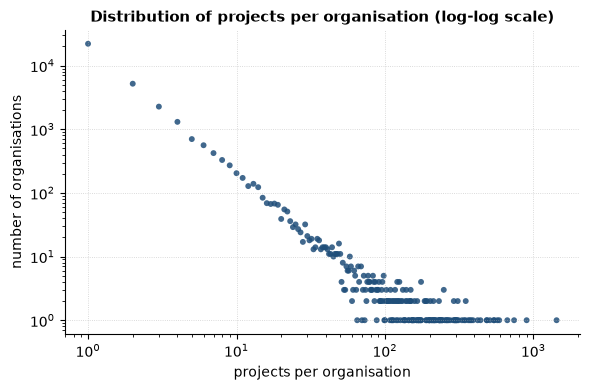

In [7]:
# Distribution of the number of projects per organisation (log-log scale)
counts = projects_per_org.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(counts.index, counts.values, s=18, color="#1f4e79", alpha=0.85, edgecolor="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("projects per organisation")
ax.set_ylabel("number of organisations")
ax.set_title("Distribution of projects per organisation (log-log scale)", fontsize=11, fontweight="bold")
ax.grid(True, which="major", linestyle=":", linewidth=0.6, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "projects_per_organisation.png", dpi=200)
plt.show()

Unlike the previous one, this distribution is close to a straight line on log-log axes over most of its range. This heavy-tailed shape, compatible with a power law, is the typical signature of a system where a few actors are far more active than the rest.

### Composition by activity type and country

We describe who takes part in the programme: the type of organisation (university, research centre, company, public body, other) and the country. Both are counted at the organisation level, one row per organisation, taking the values of its first participation. The few organisations whose values differ across participations are resolved later, in the node table, by the most frequent value.

In [8]:
# Keep the first row of each organisation, so that every organisation is counted once
organisations = participations.drop_duplicates("organisationID")

# Activity type: HES = higher education, REC = research centre, PRC = private company, PUB = public body, OTH = other
print("Organisations by activity type")
print(organisations["activityType"].value_counts(dropna=False).to_string())

print("\nOrganisations by country (top 15)")
print(organisations["country"].value_counts().head(15).to_string())

Organisations by activity type
activityType
PRC    20366
OTH     5347
REC     3544
PUB     3033
HES     2909
NaN        1

Organisations by country (top 15)
country
DE    3608
ES    3371
FR    2965
IT    2858
NL    1951
UK    1723
BE    1654
EL    1219
PT     962
AT     937
SE     921
CH     806
PL     791
FI     750
NO     747


Private companies are by far the most numerous organisations (20,366, 58%), followed by other entities (15%), research centres (10%), public bodies (9%) and universities (8%). Germany, Spain, France and Italy together host 36% of the organisations. The United Kingdom (6th) and Switzerland (12th) rank among the most represented countries.

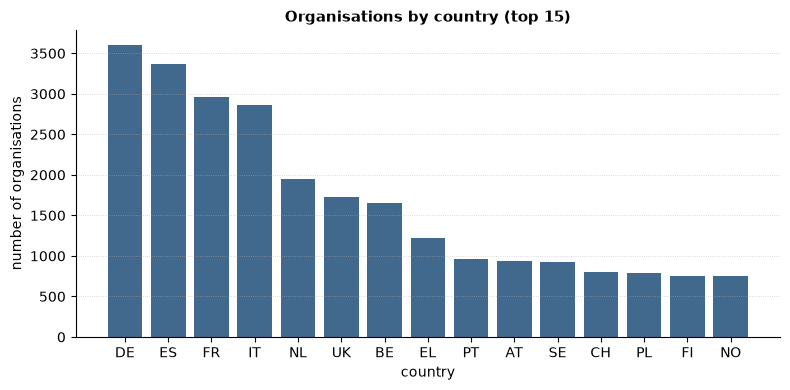

In [9]:
# Number of organisations in the 15 most represented countries
top_countries = organisations["country"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top_countries.index, top_countries.values, color="#1f4e79", alpha=0.85)
ax.set_xlabel("country")
ax.set_ylabel("number of organisations")
ax.set_title("Organisations by country (top 15)", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "organisations_by_country.png", dpi=200)
plt.show()

### Participation roles

CORDIS records each participation with one of four roles: coordinator, participant, associated partner (a member of the consortium that receives no EU funding, frequent among organisations from non-associated countries) and third party (an entity linked to a beneficiary that carries out part of the work). All four are treated as participations and generate edges (see *Construction rules*). Their distribution shows how much of the network depends on the two less conventional roles.

In [10]:
# Number of participations by role
print("Participations by role:")
print(participations["role"].value_counts().to_string())

# Countries of the associated partners
print("\nCountries of the associated partners:")
print(participations[participations["role"] == "associatedPartner"]["country"].value_counts().head(10).to_string())

Participations by role:
role
participant          91019
associatedPartner    24828
coordinator          23609
thirdParty            6175

Countries of the associated partners:
country
UK    4331
CH    2806
DE    2118
FR    1896
ES    1756
US    1513
IT    1240
NL    1015
BE     747
SE     493


Coordinators and participants together account for 79% of the participations (23,609 and 91,019 out of 145,631). Associated partners are 17% (24,828). The countries most represented in this role are the United Kingdom (4,331) and Switzerland (2,806), followed by Germany, France and Spain. Third parties are 4% (6,175), so including them, as we do, changes the network only marginally.

### Projects per start year

We count how many projects start in each year, to see which years the data cover well. Horizon Europe runs from 2021 to 2027, and a project enters CORDIS only after its grant agreement is signed, so the most recent years may still be incomplete.

In [11]:
# Number of projects starting in each year
projects_by_year = projects["startYear"].value_counts().sort_index()

print("Projects by start year:")
print(projects_by_year.to_string())

Projects by start year:
startYear
2021      30
2022    3344
2023    5130
2024    4959
2025    4468
2026    4750
2027     932


Only 30 projects start in 2021, consistent with the first calls of the programme closing during that year and their projects starting in 2022. From 2022 to 2026 the data contain between 3,300 and 5,100 projects per year, so these are the years the data cover well. The 932 projects of 2027 are those already signed at the snapshot date; 2027, and possibly 2026, are likely to grow in later releases of the dump.

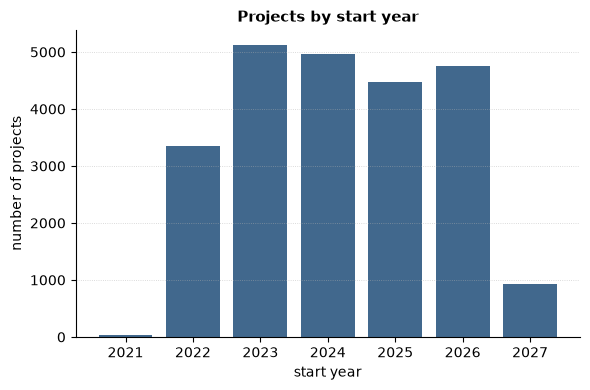

In [12]:
# Bar chart of the number of projects per start year
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(projects_by_year.index.astype(str), projects_by_year.values, color="#1f4e79", alpha=0.85)
ax.set_xlabel("start year")
ax.set_ylabel("number of projects")
ax.set_title("Projects by start year", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "projects_by_start_year.png", dpi=200)
plt.show()

### Completeness of the attributes

We measure the share of missing values in the attributes that will be attached to nodes and edges. An attribute with many missing values cannot support the analyses that depend on it, so this check tells us in advance which attributes can be used in subsequent tasks, and which cannot.

In [13]:
# Organisation attributes: missing share at the organisation level
org_attributes = ["name", "country", "activityType", "SME", "nutsCode", "geolocation"]
print("missing values, organisation attributes:")
print(organisations[org_attributes].isna().mean().map("{:.1%}".format).to_string())

# Project attributes: missing share at the project level
project_attributes = ["startDate", "fundingScheme", "policy_ai"]
print("\nmissing values, project attributes:")
print(projects[project_attributes].isna().mean().map("{:.1%}".format).to_string())

missing values, organisation attributes:
name            0.0%
country         0.0%
activityType    0.0%
SME             0.7%
nutsCode        0.7%
geolocation     4.2%

missing values, project attributes:
startDate        0.0%
fundingScheme    0.0%
policy_ai        1.2%


All the attributes are almost complete. Country, activity type, name, start date and funding scheme have no missing values. SME flag and NUTS region are missing for 0.7% of the organisations, geographic coordinates for 4.2%, and the AI policy marker for 1.2% of the projects. No attribute has to be discarded, and the analyses that rely on them can be carried out on virtually the whole network.

## Building the network

The network is built in two steps: the edge table, obtained by pairing the participants of every project, and the node table, obtained by aggregating the attributes of every organisation. The analysis of the resulting network is left to the next notebooks. Here we only check that the construction is consistent with the characterization above.

### Edges

For every project, every pair of participants becomes an edge. A pair that appears in several projects gives a single edge, whose `weight` is the number of shared projects and whose `first_year` is the start year of the earliest of them.

In [15]:
# Start year of each project, indexed by project id
project_year = projects.set_index("id")["startYear"]

# Go through the projects one by one and collect the edges in a dictionary
edge_data = {}
for project_id, group in participations.groupby("projectID"):
    year = project_year[project_id]
    orgs = sorted(group["organisationID"].unique())

    # For every pair of participants of this project: create the edge if the pair is new,
    # otherwise increase its weight and keep the earliest start year
    for a, b in combinations(orgs, 2):
        if (a, b) not in edge_data:
            edge_data[(a, b)] = [1, year]
        else:
            edge_data[(a, b)][0] += 1
            if pd.notna(year) and (pd.isna(edge_data[(a, b)][1]) or year < edge_data[(a, b)][1]):
                edge_data[(a, b)][1] = year

# Turn the dictionary into the edge table: one row per pair of linked organisations,
# with the number of shared projects (weight) and the start year of the first one (first_year)
edges = pd.DataFrame(
    [(a, b, weight, year) for (a, b), (weight, year) in edge_data.items()],
    columns=["source", "target", "weight", "first_year"],
)
edges["first_year"] = edges["first_year"].astype("Int64")

print("Edges")
print(f"  distinct edges:                 {len(edges):>8}")
print(f"  pairs with multiplicity:        {edges['weight'].sum():>8}")
print(f"  edges with weight > 1:          {(edges['weight'] > 1).sum():>8}  ({(edges['weight'] > 1).mean():.1%})")
print(f"  maximum weight:                 {edges['weight'].max():>8}")

Edges
  distinct edges:                  1061382
  pairs with multiplicity:         1335249
  edges with weight > 1:            132549  (12.5%)
  maximum weight:                      126


The sum of the weights (1,335,249) equals the number of pairs generated by the projects in the characterization, so the construction is consistent. These pairs collapse into 1,061,382 distinct edges: 12.5% of them have weight above one, i.e. the two organisations collaborated in more than one project, and the strongest tie corresponds to 126 shared projects. Most collaborations are therefore one-off, and the weight singles out a minority of recurrent partnerships.

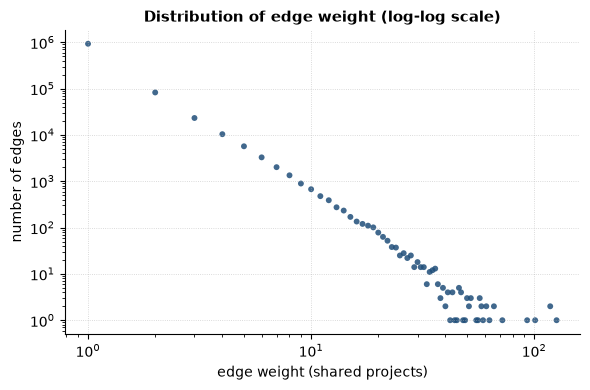

In [16]:
# Distribution of edge weight (log-log scale)
counts = edges["weight"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(counts.index, counts.values, s=18, color="#1f4e79", alpha=0.85, edgecolor="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("edge weight (shared projects)")
ax.set_ylabel("number of edges")
ax.set_title("Distribution of edge weight (log-log scale)", fontsize=11, fontweight="bold")
ax.grid(True, which="major", linestyle=":", linewidth=0.6, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "edge_weight_distribution.png", dpi=200)
plt.show()

On log-log axes the distribution is close to a straight line with a steep slope: the number of edges falls by roughly three orders of magnitude for every order of magnitude of weight.

### Nodes

Every organisation becomes a node, described by one row of the node table. Two kinds of attributes are attached to it. The descriptive attributes (name, country, NUTS region, coordinates, activity type, SME flag) characterise the organisation itself: they are read from its participations and, when they differ from one participation to another, the most frequent value is taken. The activity attributes (number of projects, projects coordinated, individual grants, total EU contribution, first and last year, average AI marker) characterise what the organisation did in the programme: they are computed by aggregating over all its projects, after attaching the project attributes to each participation.

In [17]:
# Add to each participation the attributes of its project: start year, funding scheme, AI marker
part = participations.merge(projects[["id", "startYear", "fundingScheme", "policy_ai"]],
                            left_on="projectID", right_on="id", how="left")

# Helper used below: most frequent value of a column, or None if all its values are missing
def most_frequent(values):
    mode = values.mode()
    return mode.iloc[0] if not mode.empty else None

# Descriptive attributes of the organisation: one value per organisation, the most frequent across its participations
descriptive = part.groupby("organisationID").agg(
    name=("name", most_frequent),
    country=("country", most_frequent),
    nutsCode=("nutsCode", most_frequent),
    geolocation=("geolocation", most_frequent),
    activityType=("activityType", most_frequent),
    SME=("SME", most_frequent),
)

# Activity attributes of the organisation: one value per organisation, aggregated over all its projects
activity = part.groupby("organisationID").agg(
    n_projects=("projectID", "nunique"),                                                   # number of projects
    n_coordinated=("is_coordinator", "sum"),                                               # number of projects coordinated
    n_individual=("fundingScheme", lambda s: s.str.contains("ERC|MSCA", na=False).sum()),  # number of individual grants
    ec_contribution=("ecContribution", "sum"),                                             # total EU contribution received
    first_year=("startYear", "min"),                                                       # start year of its first project
    last_year=("startYear", "max"),                                                        # start year of its last project
    ai_share=("policy_ai", "mean"),                                                        # average AI marker of its projects (0-100)
)

# Join the two groups of attributes into the node table, one row per organisation
nodes = descriptive.join(activity).reset_index().rename(columns={"organisationID": "id"})
nodes["first_year"] = nodes["first_year"].astype("Int64")
nodes["last_year"] = nodes["last_year"].astype("Int64")

# Flag the organisations that appear in no edge (all their projects have a single participant)
linked = set(edges["source"]) | set(edges["target"])
nodes["isolated"] = ~nodes["id"].isin(linked)

print("Nodes")
print(f"  organisations:                  {len(nodes):>8}")
print(f"  isolated (no edge):             {nodes['isolated'].sum():>8}  ({nodes['isolated'].mean():.1%})")
nodes.head()

Nodes
  organisations:                     35200
  isolated (no edge):                  818  (2.3%)


,id,name,country,nutsCode,geolocation,activityType,SME,n_projects,n_coordinated,n_individual,ec_contribution,first_year,last_year,ai_share,isolated
0,863062933,TOWNROCK ENERGY LIMITED,UK,UKM50,"57.2207053,-2.2419835",PRC,False,1,0,1,0.0,2025,2025,100.0,False
1,863072633,HUMANETICS EUROPE GMBH,DE,DE125,"49.364219688,8.6865900907",PRC,False,1,0,0,220625.0,2022,2022,40.0,False
2,863292920,SMART FARM ROBOTIKS,BG,BG411,None,PRC,False,1,1,0,2360936.9,2024,2024,40.0,True
3,863379735,AKCES NCBR SPOLKA Z OGRANICZONA ODPOWIEDZIALNO...,PL,PL911,"52.228983814,20.999932541",PRC,False,1,0,0,215750.0,2023,2023,100.0,False
4,863433667,City of Cape Town,ZA,ZA,None,PUB,False,1,0,0,0.0,2022,2022,0.0,False


The number of nodes equals the number of organisations in the clean participations (35,200). Only 818 organisations (2.3%) are isolated, although 46.9% of the projects have a single participant: an organisation is isolated only if all its projects are of this kind, and this happens rarely.

## Network overview

We assemble the graph with `networkx` and report its basic size and connectivity, to verify that it can be loaded and to give the reference numbers used in the next notebooks. The analysis required by Part 2 (degree distribution, components, paths, clustering, centrality, comparison with random models) is carried out in `03_network_analysis.ipynb`.

In [18]:
# Graph with all organisations as nodes, including the isolated ones, and weighted edges
G = nx.Graph()
G.add_nodes_from(nodes["id"])
G.add_weighted_edges_from(edges[["source", "target", "weight"]].itertuples(index=False, name=None))

# Largest connected component
giant = max(nx.connected_components(G), key=len)

print("Network overview")
print(f"  nodes:                          {G.number_of_nodes():>8}")
print(f"  edges:                          {G.number_of_edges():>8}")
print(f"  isolated nodes:                 {nx.number_of_isolates(G):>8}")
print(f"  connected components:           {nx.number_connected_components(G):>8}")
print(f"  largest component:              {len(giant):>8}  ({len(giant) / G.number_of_nodes():.1%} of the nodes)")
print(f"  average degree:                 {2 * G.number_of_edges() / G.number_of_nodes():>8.1f}")
print(f"  density:                        {nx.density(G):>8.5f}")

Network overview
  nodes:                             35200
  edges:                           1061382
  isolated nodes:                      818
  connected components:                864
  largest component:                 34271  (97.4% of the nodes)
  average degree:                     60.3
  density:                         0.00171


The network has 35,200 nodes and 1,061,382 edges. Besides the 818 isolated nodes, there is one giant component with 97.4% of the nodes and 45 small components. The average degree is 60 (density 0.0017): since every project links all its participants to each other, an organisation inherits as neighbours all the partners of all its projects, and the few very large projects seen in the characterization contribute a large share of these links.

## Saving the network

The network is saved as two compressed CSV files in `data/network/`: `nodes.csv.gz` (one row per organisation, with its attributes) and `edges.csv.gz` (one row per pair of linked organisations, with `weight` and `first_year`). The next notebooks load it with:

```python
nodes = pd.read_csv("../data/network/nodes.csv.gz")
edges = pd.read_csv("../data/network/edges.csv.gz")
G = nx.from_pandas_edgelist(edges, "source", "target", edge_attr=["weight", "first_year"])
G.add_nodes_from(nodes["id"])   # adds the isolated nodes
```

For the simple, undirected, unweighted network required by Part 2, the edge attributes are simply ignored.

In [20]:
# Save the node and edge tables, compressed
nodes.to_csv(NET_DIR / "nodes.csv.gz", index=False, compression="gzip")
edges.to_csv(NET_DIR / "edges.csv.gz", index=False, compression="gzip")